# Quantum Time Series Analysis: Reports
Compatible with Qiskit 1.2.4+

### Author
- Jacob L. Cybulski, Enquanted

### Date
- Feb 2025: Started

### Aims
> *This script aims to compare results obtained from running different quantum time series models.*

In [1]:
import sys
sys.path.append('.')
sys.path

['/home/jacob/miniconda3/envs/qiskit-gpu/lib/python311.zip',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11/lib-dynload',
 '',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11/site-packages',
 '.']

In [2]:
import os
import numpy as np
import pylab
import time
import copy
from tqdm.notebook import tqdm

from IPython.display import clear_output

from utils.Window import *
from utils.Charts import *
from utils.Files import *

import matplotlib.pyplot as plt
from matplotlib import set_loglevel
set_loglevel("error")
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
### Listing control
debug = True
seed = 2022

### Software version
MAJOR = 9
MINOR = 12

### Constants
LOG_NAME = 'log_4_iter'
DATA_NAME = '2_sins_sw'
DATA_PATH = f'{LOG_NAME}/data'
TRAIN_PATH = f'{LOG_NAME}/training'
ANALYSIS_PATH = f'{LOG_NAME}/analysis'
FIGURES_PATH = f'{LOG_NAME}/figures'
REPORTS_PATH = f'{LOG_NAME}/reports'

### Show constants
(LOG_NAME, DATA_NAME,DATA_PATH, TRAIN_PATH, ANALYSIS_PATH, FIGURES_PATH, REPORTS_PATH)

('log_4_iter',
 '2_sins_sw',
 'log_4_iter/data',
 'log_4_iter/training',
 'log_4_iter/analysis',
 'log_4_iter/figures',
 'log_4_iter/reports')

## Utilities

In [4]:
### Resize all arrays in a list to the longest
### Then pad them to their last value
def resize_to_equal_and_pad(arrays):
    
    # Find the length of the longest array
    max_length = max(arr.size for arr in arrays)
    
    # Function to pad an array with its last value
    def pad_array(arr, target_length):
        if arr.size >= target_length:
            return arr
        else:
            padding_length = target_length - arr.size
            padding_value = arr[-1]  # Last value of the array
            return np.pad(arr, (0, padding_length), mode='constant', constant_values=padding_value)
    
    # Pad all arrays to the length of the longest array
    return np.vstack([pad_array(arr, max_length) for arr in arrays])

## Fetch all training meta-data
**<font color="red">Enter the name of the DATA_ID</font>**<br/>
*Note that this is windowed TS data (as indicated by "sw" in the data ID)*

In [5]:
### All created files have the following codes:
DATA_ID = '2_sins_sw_t50_v20_z0_w5_s1_h1'

### Define file names

x_all_fpath = f'{DATA_PATH}/{DATA_ID}/x_all.arr'
y_all_fpath = f'{DATA_PATH}/{DATA_ID}/y_all.arr'

x_train_ts_fpath = f'{DATA_PATH}/{DATA_ID}/x_train_ts.arr'
y_train_ts_fpath = f'{DATA_PATH}/{DATA_ID}/y_train_ts.arr'
x_valid_ts_fpath = f'{DATA_PATH}/{DATA_ID}/x_valid_ts.arr'
y_valid_ts_fpath = f'{DATA_PATH}/{DATA_ID}/y_valid_ts.arr'

data_info_fpath = f'{DATA_PATH}/{DATA_ID}/info.json'
data_info_fpath

'log_4_iter/data/2_sins_sw_t50_v20_z0_w5_s1_h1/info.json'

In [6]:
### Load the info file
data_info = read_json_file(data_info_fpath)
    
### Get info details
DATA_NAME = data_info['data_name']
DATA_MAJOR = data_info['major_version'] 
DATA_MINOR = data_info['minor_version']
samples_train = data_info['data_train']
samples_valid = data_info['data_valid']
noise = data_info['data_noise']
wind_size = data_info['wind_size']
wind_step = data_info['wind_step']
horizon = data_info['wind_horizon']
seed = data_info['seed']
samples = samples_train + samples_valid
train_pc = samples_train / samples

print(f'\nSaved time series info in file "{data_info_fpath}":\n')
for k in data_info.keys():
    print(f'\tinfo[{k}] = {data_info[k]}')
print()
print(f'\tcalc[samples] = {samples}')
print(f'\tcalc[train_pc] = {train_pc}')
print()


Saved time series info in file "log_4_iter/data/2_sins_sw_t50_v20_z0_w5_s1_h1/info.json":

	info[data_name] = 2_sins_sw
	info[major_version] = 9
	info[minor_version] = 0
	info[data_train] = 50
	info[data_valid] = 20
	info[data_noise] = 0
	info[wind_size] = 5
	info[wind_step] = 1
	info[wind_horizon] = 1
	info[seed] = 2022

	calc[samples] = 70
	calc[train_pc] = 0.7142857142857143



In [7]:
### Load data files
X_all = read_ts_file(x_all_fpath)[..., None]
y_all = read_ts_file(y_all_fpath)
X_train_ts = read_ts_file(x_train_ts_fpath)
y_train_ts = read_ts_file(y_train_ts_fpath)[..., None]
X_valid_ts = read_ts_file(x_valid_ts_fpath)
y_valid_ts = read_ts_file(y_valid_ts_fpath)[..., None]
print(f'\nLoaded time series data\n')


Loaded time series data



## Plot data

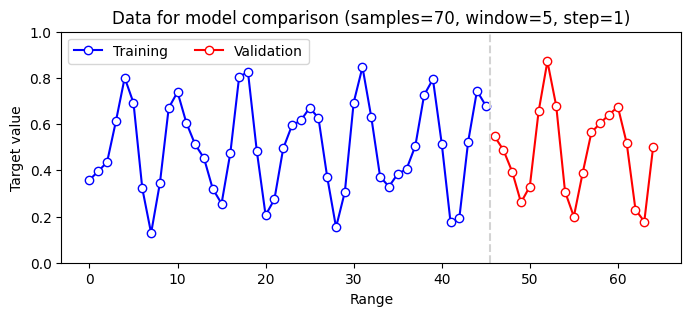

In [8]:
### Plot trainig and validation/test data partitions
#   Note that we will not use the X coordinates

y_train_flat_ts = ts_wind_flatten_avg(y_train_ts, wind_step)
y_valid_flat_ts = ts_wind_flatten_avg(y_valid_ts, wind_step)
y_list = [y_train_flat_ts, y_valid_flat_ts]
X_list = [0, len(y_train_flat_ts)]

print()
multi_plot_flat_ts(y_list, X_list=X_list, 
    colors = ['blue', 'red'], marker_colors=['white', 'white', 'lightblue', 'mistyrose'],
    labels = ['Training', 'Validation'], ylim=(0, 1),
    lines = ['solid', 'solid'], markers = ['o', 'o'], legend_cols=2,
    rcParams=(8, 3), dpi=100, 
    title=f'Data for model comparison ('+
          f'samples={samples}, window={wind_size}, step={wind_step})')
print()

## Fetch all needed training and analysis data
**<font color="red">Enter the names of all the TRAIN_IDs</font>**

In [9]:
##### Define all cases to be processed

### Selected / best models across various model types
# TRAIN_IDs = [
#     '2_sins_serial_n70_z0.0_q1_l27_L_BFGS_B_ep60',
#     '2_sins_parallel_n70_z0.0_q5_bl3_al3_L_BFGS_B_ep60',
#     '2_sins_xparallel_n70_z0.0_q5_bl3_al1_L_BFGS_B_ep60',
#     '2_sins_sw_xqnn_ng_n70_z0_q9_in5_fm1_anz5_L_BFGS_B_ep60',
#     '2_sins_sw_sliding_n70_z0_q3_xl2_il2_L_BFGS_B_ep60'
# ]

### All xparallel tests
TRAIN_IDs = [
    '2_sins_sw_sliding_n70_z0_q1_xl3_il5_L_BFGS_B_ep60',
    # '2_sins_sw_sliding_n70_z0_q1_xl4_il5_L_BFGS_B_ep60',
    '2_sins_sw_sliding_n70_z0_q2_xl2_il3_L_BFGS_B_ep60', 
    '2_sins_sw_sliding_n70_z0_q3_xl2_il2_L_BFGS_B_ep60',
    '2_sins_sw_sliding_n70_z0_q4_xl1_il2_L_BFGS_B_ep60',
    '2_sins_sw_sliding_n70_z0_q4_xl2_il2_L_BFGS_B_ep60',
]

### Optionally list the classical model results
TRAIN_CNN = ''

### Name this report
REPORT_NAME = '2_sins_sw_ovload'

### Determine all saved model instances

In [10]:
def count_weights(model_dict):
    weights_no = 0
    for key in model_dict.keys():
        if 'weight' in key:
            weights_no += len(model_dict[key].flatten())
    return weights_no

In [11]:
##### Fetch all model types and their instance lists

minf = {}
inst_list = {}
param_no = {}

# TRAIN_IDs = TRAIN_IDs if TRAIN_CNN == '' else TRAIN_IDs+[TRAIN_CNN]

print('\nList of models for further analysis\n')
for TRAIN_ID in (TRAIN_IDs if TRAIN_CNN == '' else TRAIN_IDs+[TRAIN_CNN]):
    
    ANALYSIS_PREF = TRAIN_ID

    ### Reading the model info file
    minf_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/info.json'
    minf[TRAIN_ID] = read_json_file(minf_fpath)    
    print(f'Loaded model "{minf[TRAIN_ID]["case_name"]}" ({TRAIN_ID}):')
    
    ### Collect all model valid instance numbers
    inst_list[TRAIN_ID] = []
    for sel_inst in range(minf[TRAIN_ID]['inst_no']):
        
        ### Consider the instance is found when its training history was found 
        history_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/hist.arr'
        history_fpath_pkl = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/hist.pkl'
    
        ### Check if either an arr or pkl file was found
        if  not if_path_exists(history_fpath) and not if_path_exists(history_fpath_pkl):
            print(f'\t*** ERROR: Incomplete instance: {os.path.basename(os.path.dirname(history_fpath))}')
        else:
            inst_list[TRAIN_ID].append(sel_inst)
    
        ### Check if either an arr or pkl file was found
        if TRAIN_ID not in param_no.keys():
            init_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/init.arr'
            init_fpath_pkl = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/init.pkl'
            if if_path_exists(init_fpath):
                init_params = read_ts_file(init_fpath)
                param_no[TRAIN_ID] = init_params.shape[0]
                print(f'\tParam no = {param_no[TRAIN_ID]}')
            elif if_path_exists(init_fpath_pkl):
                init_params = read_pickle_file(init_fpath_pkl)
                param_no[TRAIN_ID] = count_weights(init_params)
                print(f'\tParam no = {param_no[TRAIN_ID]}')
            else:
                print(f'\t*** ERROR: Missing params init: {os.path.basename(os.path.dirname(init_fpath))}')

    print(f'\twith instances: {inst_list[TRAIN_ID]}\n')


List of models for further analysis

Loaded model "sliding" (2_sins_sw_sliding_n70_z0_q1_xl3_il5_L_BFGS_B_ep60):
	Param no = 92
	with instances: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Loaded model "sliding" (2_sins_sw_sliding_n70_z0_q2_xl2_il3_L_BFGS_B_ep60):
	Param no = 81
	with instances: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Loaded model "sliding" (2_sins_sw_sliding_n70_z0_q3_xl2_il2_L_BFGS_B_ep60):
	Param no = 88
	with instances: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Loaded model "sliding" (2_sins_sw_sliding_n70_z0_q4_xl1_il2_L_BFGS_B_ep60):
	Param no = 71
	with instances: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Loaded model "sliding" (2_sins_sw_sliding_n70_z0_q4_xl2_il2_L_BFGS_B_ep60):
	Param no = 119
	with instances: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]



### Collect analysis data for all quantum model instances

In [12]:
##### Collect all model analysis data

### Initialise a list of empty instances
insts = {}

### Load all analysis data for quantum models
print()
for TRAIN_ID in TRAIN_IDs:
    
    ANALYSIS_PREF = TRAIN_ID

    ### Reading the model info file
    print(f'Loading instance scores for model "{minf[TRAIN_ID]["case_name"]:<10}": ', end='')
    
    insts[TRAIN_ID] = {}
    inst_no = len(inst_list[TRAIN_ID])
    
    ### Init predictions for all instances
    insts[TRAIN_ID]['train_preds'] = [[]] * inst_no
    insts[TRAIN_ID]['test_preds'] = [[]] * inst_no
    
    ### Init scores
    insts[TRAIN_ID]['train_mae'] = [[]] * inst_no
    insts[TRAIN_ID]['train_mse'] = [[]] * inst_no
    insts[TRAIN_ID]['train_r2'] = [[]] * inst_no
    insts[TRAIN_ID]['test_mae'] = [[]] * inst_no
    insts[TRAIN_ID]['test_mse'] = [[]] * inst_no
    insts[TRAIN_ID]['test_r2'] = [[]] * inst_no
    
    for inst_idx in range(inst_no):
        
        ### Find real instance number
        sel_inst = inst_list[TRAIN_ID][inst_idx]
    
        ### Training info files 
        train_preds_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_preds.arr'
        train_mae_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_mae_scores.arr'
        train_mse_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_mse_scores.arr'
        train_r2_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_r2_scores.arr'    
        test_preds_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_preds.arr'
        test_mae_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_mae_scores.arr'
        test_mse_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_mse_scores.arr'
        test_r2_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_r2_scores.arr'
    
        ### Read the scores
        insts[TRAIN_ID]['train_preds'][inst_idx] = read_ts_file(train_preds_fpath)
        insts[TRAIN_ID]['train_mae'][inst_idx] = read_ts_file(train_mae_scores_fpath)
        insts[TRAIN_ID]['train_mse'][inst_idx] = read_ts_file(train_mse_scores_fpath)
        insts[TRAIN_ID]['train_r2'][inst_idx] = read_ts_file(train_r2_scores_fpath)
    
        insts[TRAIN_ID]['test_preds'][inst_idx] = read_ts_file(test_preds_fpath)
        insts[TRAIN_ID]['test_mae'][inst_idx] = read_ts_file(test_mae_scores_fpath)
        insts[TRAIN_ID]['test_mse'][inst_idx] = read_ts_file(test_mse_scores_fpath)
        insts[TRAIN_ID]['test_r2'][inst_idx] = read_ts_file(test_r2_scores_fpath)
    
        print(f'{sel_inst} ', end='')

    print(f' ({TRAIN_ID})')
    print()


Loading instance scores for model "sliding   ": 0 1 2 3 4 5 6 7 8 9  (2_sins_sw_sliding_n70_z0_q1_xl3_il5_L_BFGS_B_ep60)

Loading instance scores for model "sliding   ": 0 1 2 3 4 5 6 7 8 9  (2_sins_sw_sliding_n70_z0_q2_xl2_il3_L_BFGS_B_ep60)

Loading instance scores for model "sliding   ": 0 1 2 3 4 5 6 7 8 9  (2_sins_sw_sliding_n70_z0_q3_xl2_il2_L_BFGS_B_ep60)

Loading instance scores for model "sliding   ": 0 1 2 3 4 5 6 7 8 9  (2_sins_sw_sliding_n70_z0_q4_xl1_il2_L_BFGS_B_ep60)

Loading instance scores for model "sliding   ": 0 1 2 3 4 5 6 7 8 9  (2_sins_sw_sliding_n70_z0_q4_xl2_il2_L_BFGS_B_ep60)



### Add analysis data for the classical model instances

In [13]:
if TRAIN_CNN != '':

    ### Load all analysis data for quantum models
    TRAIN_ID = TRAIN_CNN
    ANALYSIS_PREF = TRAIN_ID
    
    ### Reading the model info file
    print(f'\nLoading model scores for the "{minf[TRAIN_ID]["case_name"]}" model instances: ', end='')
    
    insts[TRAIN_ID] = {}
    inst_no = len(inst_list[TRAIN_ID])
    
    ### Init predictions for all instances
    insts[TRAIN_ID]['train_preds'] = [[]] * inst_no
    insts[TRAIN_ID]['test_preds'] = [[]] * inst_no
    
    ### Init scores
    insts[TRAIN_ID]['train_mae'] = [[]] * inst_no
    insts[TRAIN_ID]['train_mse'] = [[]] * inst_no
    insts[TRAIN_ID]['train_r2'] = [[]] * inst_no
    insts[TRAIN_ID]['test_mae'] = [[]] * inst_no
    insts[TRAIN_ID]['test_mse'] = [[]] * inst_no
    insts[TRAIN_ID]['test_r2'] = [[]] * inst_no
    
    for inst_idx in range(inst_no):
        
        ### Find real instance number
        sel_inst = inst_list[TRAIN_ID][inst_idx]
    
        ### Training info files 
        train_preds_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_preds.pkl'
        train_mae_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_mae_scores.pkl'
        train_mse_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_mse_scores.pkl'
        train_r2_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_r2_scores.pkl'    
        test_preds_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_preds.pkl'
        test_mae_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_mae_scores.pkl'
        test_mse_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_mse_scores.pkl'
        test_r2_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_r2_scores.pkl'
    
        ### Read the scores
        insts[TRAIN_ID]['train_preds'][inst_idx] = read_pickle_file(train_preds_fpath)
        insts[TRAIN_ID]['train_mae'][inst_idx] = read_pickle_file(train_mae_scores_fpath)
        insts[TRAIN_ID]['train_mse'][inst_idx] = read_pickle_file(train_mse_scores_fpath)
        insts[TRAIN_ID]['train_r2'][inst_idx] = read_pickle_file(train_r2_scores_fpath)
    
        insts[TRAIN_ID]['test_preds'][inst_idx] = read_pickle_file(test_preds_fpath)
        insts[TRAIN_ID]['test_mae'][inst_idx] = read_pickle_file(test_mae_scores_fpath)
        insts[TRAIN_ID]['test_mse'][inst_idx] = read_pickle_file(test_mse_scores_fpath)
        insts[TRAIN_ID]['test_r2'][inst_idx] = read_pickle_file(test_r2_scores_fpath)
    
        print(f'{sel_inst} ', end='')
    
    print(f' ({TRAIN_ID})')
    print()

In [14]:
### List of all loaded models
for key in insts.keys():
    print(f'model: {minf[key]["case_name"]:<10} ({key})')

model: sliding    (2_sins_sw_sliding_n70_z0_q1_xl3_il5_L_BFGS_B_ep60)
model: sliding    (2_sins_sw_sliding_n70_z0_q2_xl2_il3_L_BFGS_B_ep60)
model: sliding    (2_sins_sw_sliding_n70_z0_q3_xl2_il2_L_BFGS_B_ep60)
model: sliding    (2_sins_sw_sliding_n70_z0_q4_xl1_il2_L_BFGS_B_ep60)
model: sliding    (2_sins_sw_sliding_n70_z0_q4_xl2_il2_L_BFGS_B_ep60)


## Produce reports for the selected models

In [15]:
### Find the median and its location in a list
def arg_median(lst):
    sorted_lst = sorted(lst)
    n = len(sorted_lst)
    if n % 2 == 1: # odd number of elements, the median is the middle element
        median_value = sorted_lst[n // 2]
    else: # even number of elements, the median is the average of the two middle elements
        median_value = sorted_lst[n // 2 - 1]    
    median_index = lst.index(median_value)    
    return median_index, median_value

In [16]:
### Create a report text with headings
report = f'Data\tModel\tSpecs\tQubits\tParams\tEpochs'+\
         f'\tTr_Med_R2\tTr_Med_MSE\tTr_Med_MAE\tTs_Med_R2\tTs_Med_MSE\tTs_Med_MAE'

### Create a table of important info
print()
print(f"{'Report:':<10} {REPORT_NAME+' (median)':<31}  {'Training':>20} {'Testing':>20}\n")
print(f"{'Data':<10} {'Model':<10} {'Qubits':<7} {'Params':<7} {'Epochs':<7}  "+\
      f"{'R2':>6} {'MSE':>6} {'MAE':>6} {'R2':>6} {'MSE':>6} {'MAE':>6}   Model Specs")
for key in insts.keys():
    ### Get standard info
    data = minf[key]["data_name"]
    model = minf[key]["case_name"]
    opt_name = minf[key]["opt_name"]
    qubits = 0
    if "ansatz_qubits" in minf[key]:
        qubits = minf[key]["ansatz_qubits"]
    epochs = minf[key]["epochs"]

    ### Fetch precalculated info
    params = param_no[key]
    
    ### Calculate median scores
    
    # Find the instance with the median min MSE score
    insts_test_mse_scores = insts[key]['test_mse']
    insts_test_min_mse_scores = [float(np.min(inst_mses)) for inst_mses in insts_test_mse_scores]
    sel_inst, sel_median_test_score = arg_median(insts_test_min_mse_scores)
    sel_params_no = int(np.argmin(insts_test_mse_scores[sel_inst]))

    # Calculate stats    
    tr_r2_med = insts[key]['train_r2'][sel_inst][sel_params_no]
    tr_mae_med = insts[key]['train_mae'][sel_inst][sel_params_no]
    tr_mse_med = insts[key]['train_mse'][sel_inst][sel_params_no]
    ts_r2_med = insts[key]['test_r2'][sel_inst][sel_params_no]
    ts_mae_med = insts[key]['test_mae'][sel_inst][sel_params_no]
    ts_mse_med = insts[key]['test_mse'][sel_inst][sel_params_no]

    # Extract model details
    key_det = key[len(data)+1:]
    key_det = key_det[len(model)+1+4:]
    key_det = key_det[key_det.find('_')+1:]
    key_det = key_det[:key_det.find(opt_name)-1]
    key_det = key_det.replace('_', ' ')

    # Print details
    print(f"{data:<10} {model:<10} {' ':<4}{qubits:2d} {' ':<2}{params:5d} {' ':<5}{epochs:02d}  "+\
          f"{' ':<1}{tr_r2_med:0.4f} {tr_mse_med:0.4f} {tr_mae_med:0.4f} "+\
          f"{ts_r2_med:0.4f} {ts_mse_med:0.4f} {ts_mae_med:0.4f}   {key_det}")

    # Add the record to the report
    report = f'{report}\n'+\
        f'{data}\t{model}\t{key_det}\t{qubits}\t{params}\t{epochs}'+\
        f'\t{tr_r2_med}\t{tr_mse_med}\t{tr_mae_med}'+\
        f'\t{ts_r2_med}\t{ts_mse_med}\t{ts_mae_med}'

### Save the report
print()
write_csv_file(f'{REPORTS_PATH}/{REPORT_NAME}.tsv', report)

# print()
# print(report)


Report:    2_sins_sw_ovload (median)                    Training              Testing

Data       Model      Qubits  Params  Epochs       R2    MSE    MAE     R2    MSE    MAE   Model Specs
2_sins_sw  sliding         1      92      60   0.2316 0.0303 0.1468 0.1560 0.0295 0.1483   q1 xl3 il5
2_sins_sw  sliding         2      81      60   0.7848 0.0085 0.0771 0.7697 0.0081 0.0720   q2 xl2 il3
2_sins_sw  sliding         3      88      60   0.8719 0.0050 0.0618 0.8504 0.0052 0.0590   q3 xl2 il2
2_sins_sw  sliding         4      71      60   0.8839 0.0046 0.0579 0.8668 0.0047 0.0560   q4 xl1 il2
2_sins_sw  sliding         4     119      60   0.8866 0.0045 0.0566 0.8723 0.0045 0.0558   q4 xl2 il2



## System

In [17]:
import os
import sys
print(f"\nOperating environment:\n")
os.system('lsb_release -d -s')
os.system('python --version')
print(f'Conda {os.path.basename(sys.prefix)}\n')


Operating environment:

Ubuntu 22.04.5 LTS
Python 3.11.11
Conda qiskit-gpu



In [18]:
print(f"\nSignificant Python packages:\n")
os.system('pip list | grep -e qiskit');


Significant Python packages:

qiskit                        1.2.4
qiskit-aer-gpu                0.15.1
qiskit-algorithms             0.3.1
qiskit-ibm-runtime            0.32.0
qiskit-machine-learning       0.8.1
qiskit-optimization           0.6.1
qiskit-sphinx-theme           1.16.1
